- This notebook is structured to simulate a controlled ablation study, where key hyperparameters (padding and stride) are systematically varied.
- Such methodology is widely used in research and industry to evaluate architectural trade-offs.
- Metrics such as accuracy, training time, and parameter count are used to assess both performance and efficiency.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### Load & Prepare MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Train shape: (60000, 28, 28, 1)
Test  shape: (10000, 28, 28, 1)


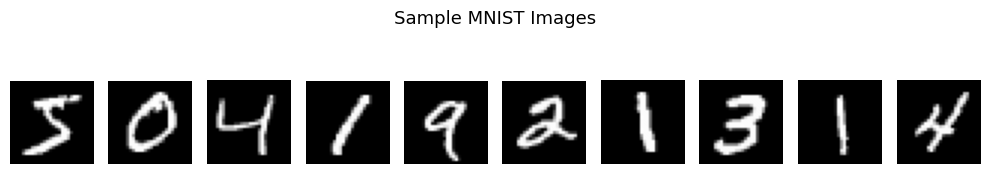

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, -1)  # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test,  -1)  # (10000, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test,  10)

print("Train shape:", x_train.shape)
print("Test  shape:", x_test.shape)

# Visualize sample images
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("Sample MNIST Images", fontsize=13)
plt.tight_layout()
plt.show()


### Output Shape Tracker

In [3]:
def get_conv_output_shapes(padding, strides, kernel_size=3):
    """
    Manually compute output shapes through conv + pool layers.
    Helps understand how spatial dimensions shrink.
    """
    H, W = 28, 28
    K = kernel_size
    S = strides[0]

    shapes = [("Input", H, W)]

    # Conv1
    if padding == 'same':
        H1 = int(np.ceil(H / S))
        W1 = int(np.ceil(W / S))
    else:
        H1 = int((H - K) / S) + 1
        W1 = int((W - K) / S) + 1
    shapes.append(("After Conv1", H1, W1))

    # MaxPool1 (2x2, stride 2)
    H1p = H1 // 2
    W1p = W1 // 2
    shapes.append(("After Pool1", H1p, W1p))

    # Conv2
    if padding == 'same':
        H2 = int(np.ceil(H1p / S))
        W2 = int(np.ceil(W1p / S))
    else:
        H2 = max(int((H1p - K) / S) + 1, 0)
        W2 = max(int((W1p - K) / S) + 1, 0)
    shapes.append(("After Conv2", H2, W2))

    # MaxPool2 (2x2, stride 2)
    H2p = max(H2 // 2, 1)
    W2p = max(W2 // 2, 1)
    shapes.append(("After Pool2", H2p, W2p))

    print(f"\n Spatial dimension flow (padding='{padding}', stride={S}):")
    print(f"  {'Layer':<20} {'Height':>8} {'Width':>8}")
    print(f"  {'-'*38}")
    for name, h, w in shapes:
        print(f"  {name:<20} {h:>8} {w:>8}")
    
    return H2p, W2p


### Build CNN with BatchNorm

In [4]:
def build_cnn(padding='same', strides=(1,1), kernel_size=3, name="model"):
    """
    Builds a CNN with:
    - 2x Conv2D blocks (each with BatchNorm + ReLU)
    - MaxPooling after each block
    - Dense head with Dropout
    """
    # Check if feature map will collapse
    fh, fw = get_conv_output_shapes(padding, strides, kernel_size)
    if fh == 0 or fw == 0:
        print(f"  ⚠️  Skipping '{name}': feature map collapsed to 0!")
        return None

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Block 1
        layers.Conv2D(32, kernel_size, padding=padding, strides=strides, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        layers.Conv2D(64, kernel_size, padding=padding, strides=strides, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name=name)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


### Define Experiments

In [5]:
experiments = [
    {"name": "same_s1",  "label": "Same padding, Stride 1 (Baseline)", "padding": "same",  "strides": (1,1)},
    {"name": "valid_s1", "label": "Valid padding, Stride 1",            "padding": "valid", "strides": (1,1)},
    {"name": "same_s2",  "label": "Same padding, Stride 2",             "padding": "same",  "strides": (2,2)},
    {"name": "valid_s2", "label": "Valid padding, Stride 2",            "padding": "valid", "strides": (2,2)},
    {"name": "same_s3",  "label": "Same padding, Stride 3",             "padding": "same",  "strides": (3,3)},
]


###  Run All Experiments

In [6]:
results  = []
histories = {}

EPOCHS     = 8
BATCH_SIZE = 128

for exp in experiments:
    print(f"\n{'='*60}")
    print(f" Experiment: {exp['label']}")
    print(f"{'='*60}")

    model = build_cnn(
        padding=exp["padding"],
        strides=exp["strides"],
        name=exp["name"]
    )

    if model is None:
        continue

    model.summary()

    start = time.time()
    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        verbose=1
    )
    elapsed = time.time() - start

    _, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "Config"      : exp["label"],
        "Padding"     : exp["padding"],
        "Stride"      : str(exp["strides"]),
        "Params"      : model.count_params(),
        "Train Time(s)": round(elapsed, 1),
        "Test Acc"    : round(test_acc * 100, 2),
        "Val Acc"     : round(history.history['val_accuracy'][-1] * 100, 2),
    })

    histories[exp["label"]] = history

    # Save model for potential reuse
    model.save(f"{exp['name']}.keras")
    print(f"\n✅ Done — Test Accuracy: {test_acc*100:.2f}% | Time: {elapsed:.1f}s")



🔬 Experiment: Same padding, Stride 1 (Baseline)

📐 Spatial dimension flow (padding='same', stride=1):
  Layer                  Height    Width
  --------------------------------------
  Input                      28       28
  After Conv1                28       28
  After Pool1                14       14
  After Conv2                14       14
  After Pool2                 7        7


Model: "same_s1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,930 (1.61 MB)

 Trainable params: 421,738 (1.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 10, 10, 32)          │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 10, 10, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 10, 10, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 2, 2, 64)            │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 2, 2, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,714 (112.16 KB)

 Trainable params: 28,522 (111.41 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8530 - loss: 0.4679 - val_accuracy: 0.7620 - val_loss: 0.7038
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9459 - loss: 0.1751 - val_accuracy: 0.9660 - val_loss: 0.1059
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9592 - loss: 0.1338 - val_accuracy: 0.9700 - val_loss: 0.0954
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9641 - loss: 0.1140 - val_accuracy: 0.9713 - val_loss: 0.0913
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9686 - loss: 0.1000 - val_accuracy: 0.9750 - val_loss: 0.0840
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9726 - loss: 0.0864 - val_accuracy: 0.9742 - val_loss: 0.0829
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9742 - loss: 0.0785 - val_accuracy: 0.9737 - val_loss: 0.0830
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9754 - loss: 0.0748 - val_accuracy:

### Results Summary Table

In [7]:
df = pd.DataFrame(results)
print("\n" + "="*80)
print(" EXPERIMENT RESULTS SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)


📊 EXPERIMENT RESULTS SUMMARY
                           Config Padding Stride  Params  Train Time(s)  Test Acc  Val Acc
Same padding, Stride 1 (Baseline)    same (1, 1)  421930          390.8     98.90    98.93
          Valid padding, Stride 1   valid (1, 1)  225322          281.9     99.11    99.13
           Same padding, Stride 2    same (2, 2)   53290           93.2     98.76    98.80
          Valid padding, Stride 2   valid (2, 2)   28714           75.5     97.92    98.08
           Same padding, Stride 3    same (3, 3)   28714           75.6     97.27    97.45


### Plot: Accuracy Curves Per Config

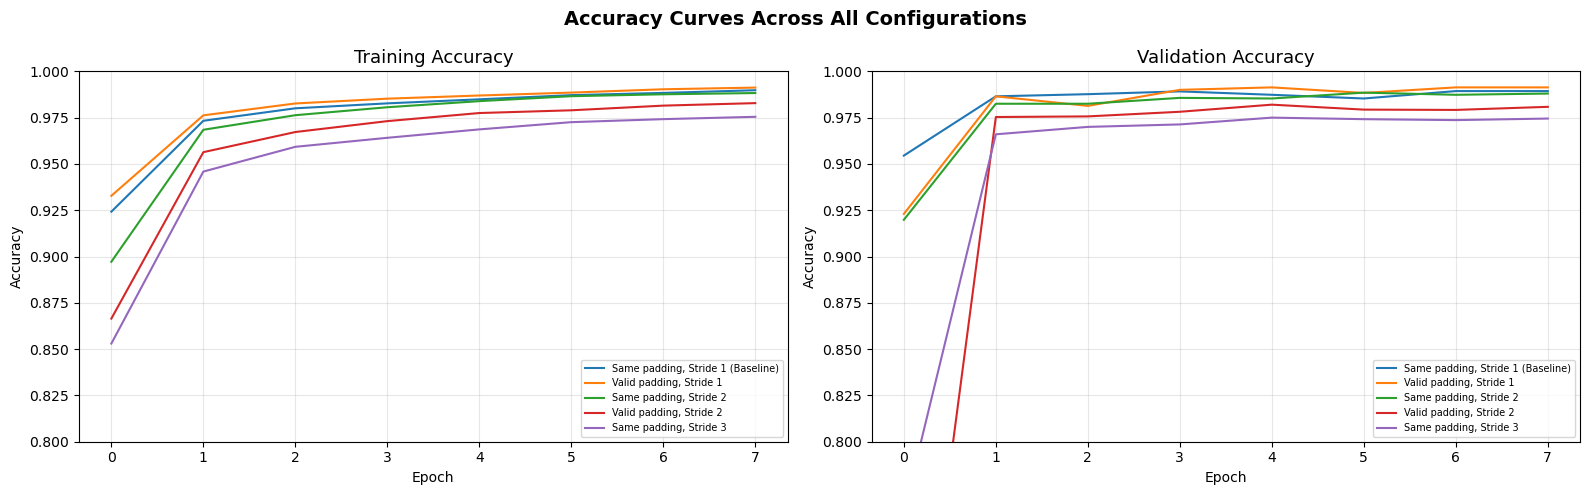

✅ Saved: accuracy_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, hist in histories.items():
    axes[0].plot(hist.history['accuracy'],     label=label)
    axes[1].plot(hist.history['val_accuracy'], label=label)

for ax, title in zip(axes, ["Training Accuracy", "Validation Accuracy"]):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.8, 1.0])

plt.suptitle("Accuracy Curves Across All Configurations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("accuracy_curves.png", dpi=150)
plt.show()
print("✅ Saved: accuracy_curves.png")


### Bar Charts: Accuracy, Params, Time

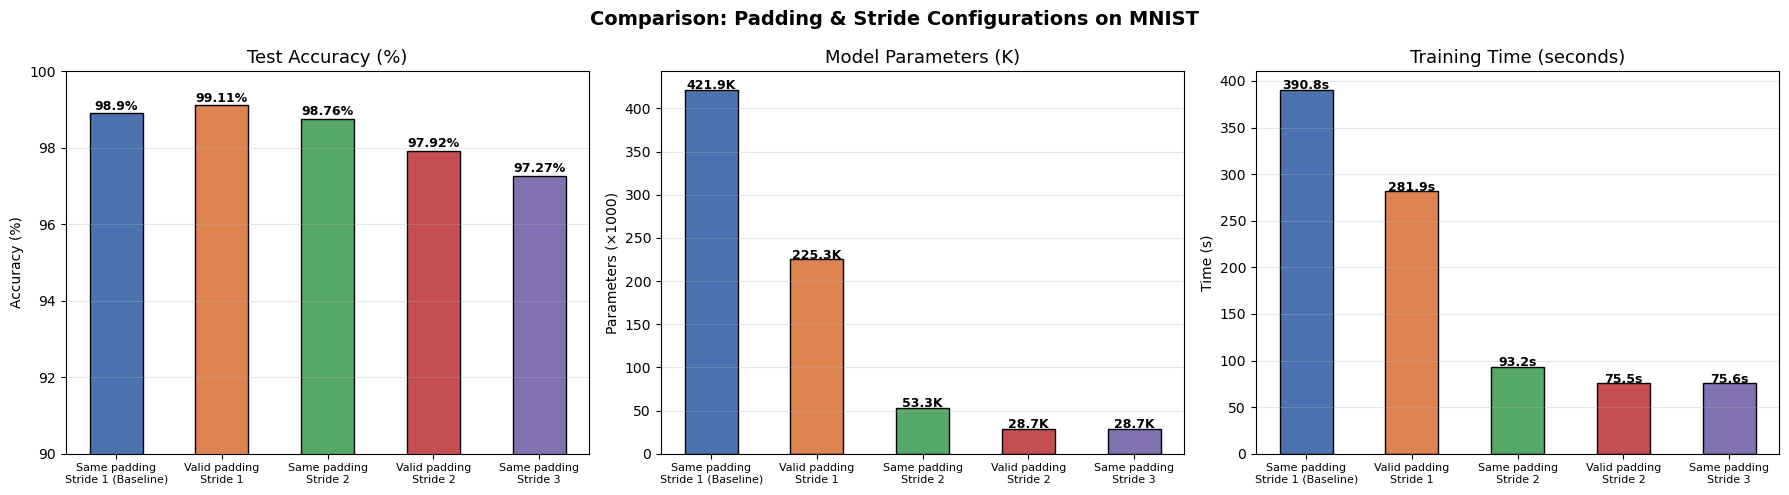

✅ Saved: comparison_charts.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels      = [r["Config"].replace(", ", "\n") for r in results]
test_accs   = [r["Test Acc"]      for r in results]
params      = [r["Params"] / 1e3  for r in results]   # in thousands
train_times = [r["Train Time(s)"] for r in results]

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

# Accuracy
axes[0].bar(labels, test_accs, color=colors, edgecolor='black', width=0.5)
axes[0].set_title("Test Accuracy (%)", fontsize=13)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim([90, 100])
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.1, f"{v}%", ha='center', fontsize=9, fontweight='bold')

# Parameters
axes[1].bar(labels, params, color=colors, edgecolor='black', width=0.5)
axes[1].set_title("Model Parameters (K)", fontsize=13)
axes[1].set_ylabel("Parameters (×1000)")
for i, v in enumerate(params):
    axes[1].text(i, v + 0.5, f"{v:.1f}K", ha='center', fontsize=9, fontweight='bold')

# Training Time
axes[2].bar(labels, train_times, color=colors, edgecolor='black', width=0.5)
axes[2].set_title("Training Time (seconds)", fontsize=13)
axes[2].set_ylabel("Time (s)")
for i, v in enumerate(train_times):
    axes[2].text(i, v + 0.5, f"{v}s", ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Comparison: Padding & Stride Configurations on MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=150)
plt.show()
print("✅ Saved: comparison_charts.png")


### Visualize Conv Layer Activations (Baseline)

✅ Found first Conv2D layer: conv2d
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Activation map shape: (1, 28, 28, 32)


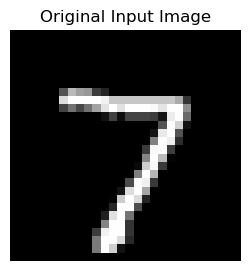

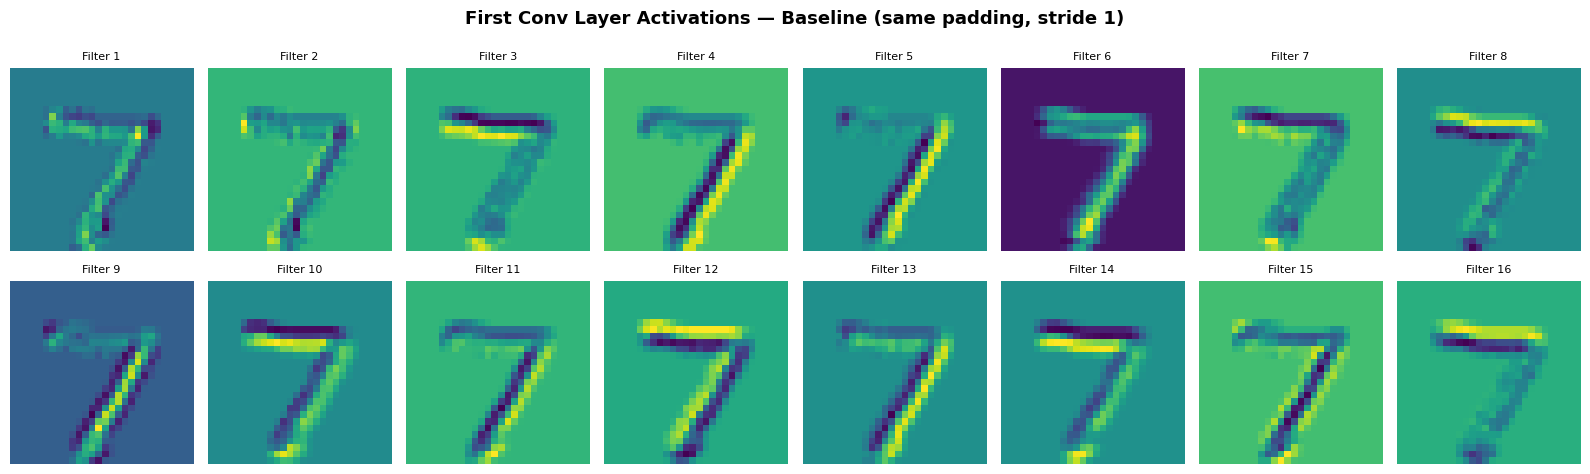

✅ Saved: activations_baseline.png


In [12]:
# Load baseline model
baseline_model = keras.models.load_model("same_s1.keras")

# Fix: build a fresh functional model using the same architecture
# by passing a dummy input through to "wake up" the layers
dummy_input = tf.zeros((1, 28, 28, 1))
_ = baseline_model(dummy_input)  # ← this call registers inbound nodes

# Now extract first Conv2D layer's output
first_conv_layer = None
for layer in baseline_model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv_layer = layer
        break

print(f"✅ Found first Conv2D layer: {first_conv_layer.name}")

# Build intermediate model properly
activation_model = keras.Model(
    inputs=baseline_model.inputs,       # ← use .inputs (plural) not .input
    outputs=first_conv_layer.output
)

# Pick first test image
sample = x_test[:1]   # shape (1, 28, 28, 1)
activations = activation_model.predict(sample)  # (1, H, W, 32)
print(f"Activation map shape: {activations.shape}")

# Show original image
plt.figure(figsize=(3, 3))
plt.imshow(sample[0, :, :, 0], cmap='gray')
plt.title("Original Input Image")
plt.axis('off')
plt.show()

# Show first 16 feature maps
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    if i < activations.shape[-1]:
        vmin = activations[0, :, :, i].min()
        vmax = activations[0, :, :, i].max()
        ax.imshow(activations[0, :, :, i], cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set_title(f"Filter {i+1}", fontsize=8)
    ax.axis('off')

plt.suptitle("First Conv Layer Activations — Baseline (same padding, stride 1)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("activations_baseline.png", dpi=150)
plt.show()
print("✅ Saved: activations_baseline.png")



## Conclusion

This experiment demonstrates the critical role of padding and stride in controlling the balance between model performance and computational efficiency.

### Key Insights:
1. **Same padding** preserves spatial dimensions, allowing better feature extraction and higher accuracy.
2. **Valid padding** reduces dimensions and computation but may lose edge information.
3. **Higher stride values** reduce computation and speed up training but result in loss of fine details.
4. The best trade-off observed is **same padding with stride (1,1)**.

### Real-World Relevance:
- Same padding + low stride → medical imaging, segmentation tasks  
- High stride → mobile and edge devices  
- Balanced configurations → autonomous driving and real-time systems  

Overall, CNN design is a trade-off between accuracy and efficiency, and the optimal configuration depends on application requirements.
